# Customer Clustering (Unsupervised) - Refactored

This refactored notebook segments customers using K-means on scaled RFM features from Day 2. We'll use modular functions for loading/scaling, elbow/silhouette evaluation, fitting/assigning, visualization, MLflow logging, and saving. This improves reusability and testing. Adjust k based on plots (plan suggests 4).

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import mlflow
from mpl_toolkits.mplot3d import Axes3D  # For optional 3D plot

## 1. Load and Scale RFM Features
Load the RFM DataFrame and scale the features (Recency, Frequency, Monetary) using StandardScaler to ensure equal weighting in clustering.

In [2]:
def load_rfm(file_path='data/rfm_features.csv'):
    """Load RFM DataFrame from CSV."""
    rfm = pd.read_csv(file_path)
    return rfm

rfm = load_rfm()

def scale_rfm(rfm):
    """Scale RFM features and return scaled array."""
    scaler = StandardScaler()
    rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
    return rfm_scaled

rfm_scaled = scale_rfm(rfm)

## 2. Elbow Plot for Optimal K
Compute inertia for k=1 to 10 and plot the elbow curve to identify a potential optimal number of clusters.

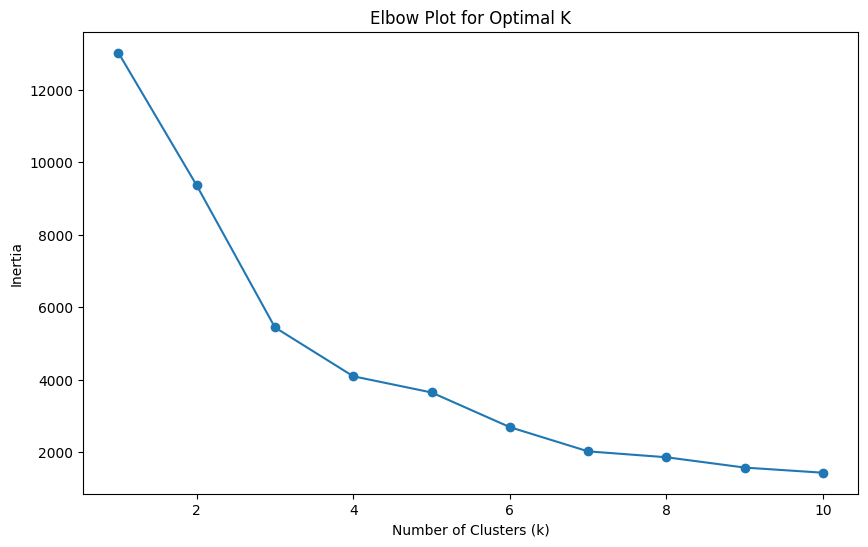

In [3]:
def compute_elbow(rfm_scaled, k_range=range(1, 11)):
    """Compute inertia for given k range."""
    inertia = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(rfm_scaled)
        inertia.append(kmeans.inertia_)
    return inertia, k_range

inertia, k_range = compute_elbow(rfm_scaled)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Plot for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

## 3. Silhouette Scores for Different K
Compute silhouette scores for k=2 to 10 (measures cluster cohesion/separation) and plot to help select k.

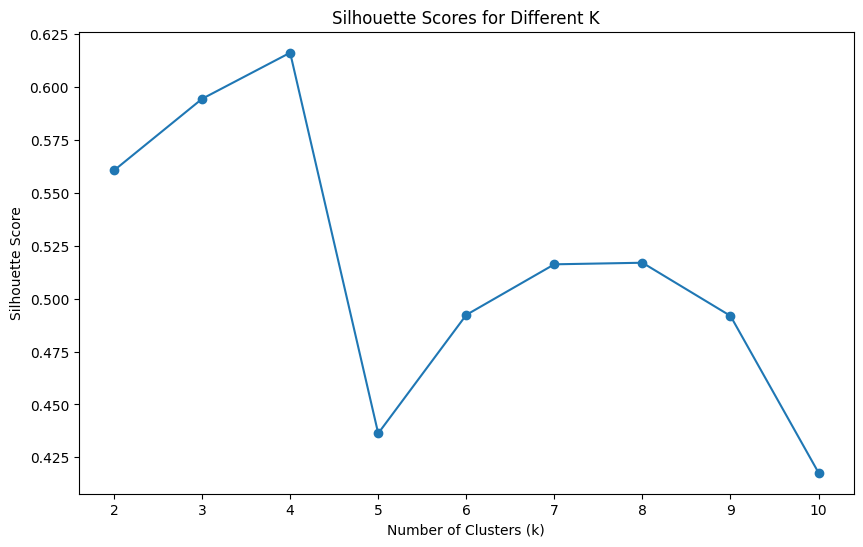

In [4]:
def compute_silhouette(rfm_scaled, k_range=range(2, 11)):
    """Compute silhouette scores for given k range."""
    sil_scores = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        clusters = kmeans.fit_predict(rfm_scaled)
        sil_scores.append(silhouette_score(rfm_scaled, clusters))
    return sil_scores, k_range

sil_scores, sil_k_range = compute_silhouette(rfm_scaled)

plt.figure(figsize=(10, 6))
plt.plot(sil_k_range, sil_scores, marker='o')
plt.title('Silhouette Scores for Different K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

## 4. Fit K-Means and Assign Cluster Labels
Choose k based on the plots (e.g., 4 as per plan), fit the KMeans model, and add the 'Cluster' labels to the RFM DataFrame.

In [5]:
def fit_and_assign_clusters(rfm, rfm_scaled, k=4):
    """Fit K-means and assign cluster labels to RFM."""
    kmeans = KMeans(n_clusters=k, random_state=42)
    rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
    return rfm, kmeans

# Choose k (adjust based on plots)
k = 4
rfm, kmeans = fit_and_assign_clusters(rfm, rfm_scaled, k)

## 5. Visualize Clusters
Create scatterplots (and optional 3D) to visualize the clusters, colored by Cluster label.

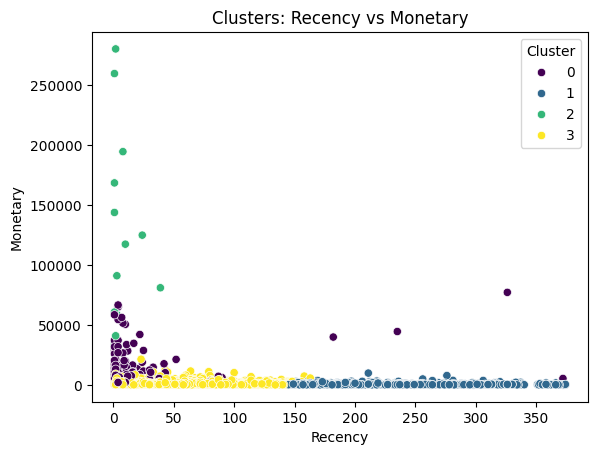

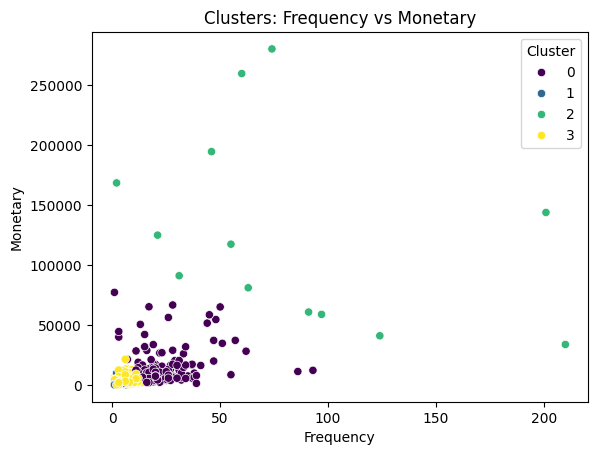

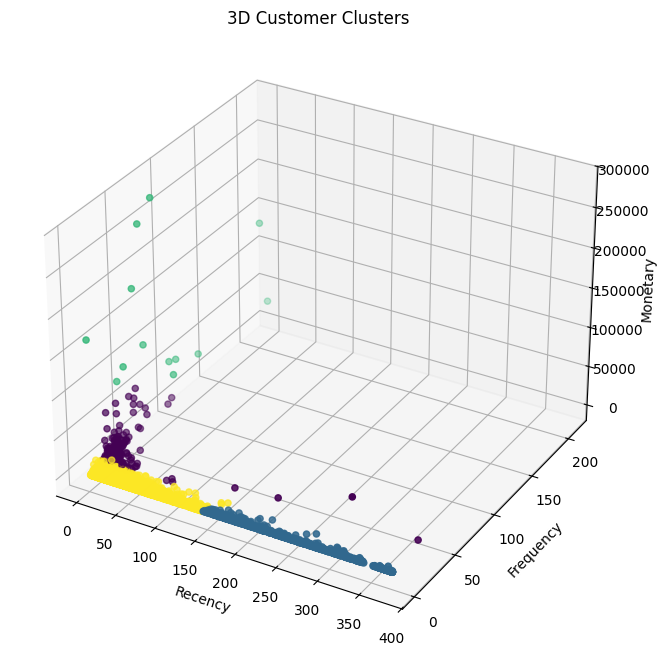

In [6]:
def visualize_clusters(rfm):
    """Visualize 2D scatterplots and optional 3D plot of clusters."""
    # 2D Scatterplots
    sns.scatterplot(x='Recency', y='Monetary', hue='Cluster', data=rfm, palette='viridis')
    plt.title('Clusters: Recency vs Monetary')
    plt.show()

    sns.scatterplot(x='Frequency', y='Monetary', hue='Cluster', data=rfm, palette='viridis')
    plt.title('Clusters: Frequency vs Monetary')
    plt.show()

    # Optional 3D plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis')
    ax.set_xlabel('Recency')
    ax.set_ylabel('Frequency')
    ax.set_zlabel('Monetary')
    plt.title('3D Customer Clusters')
    plt.show()

visualize_clusters(rfm)

## 6. Log Experiment with MLflow
Set up an MLflow experiment, log parameters/metrics (e.g., k, inertia, silhouette), the model, and artifacts (e.g., plots).

2025/09/29 02:17:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/29 02:17:11 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


MLflow run logged successfully


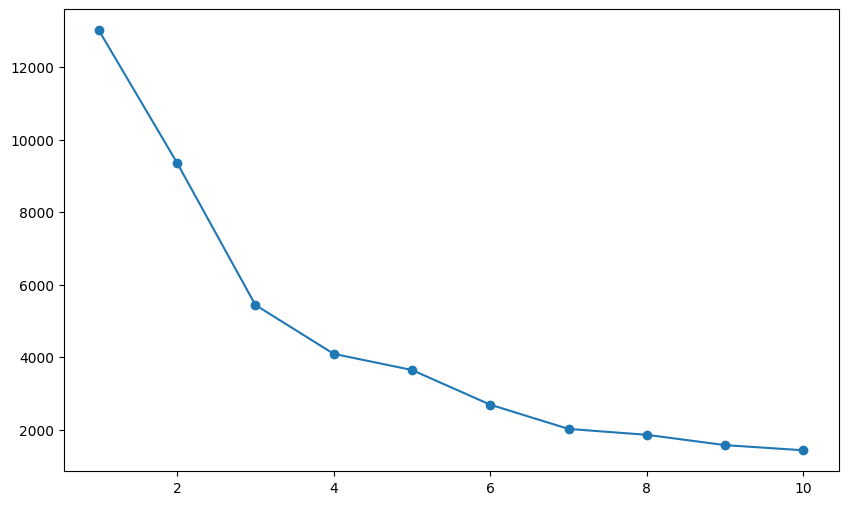

In [7]:
def log_mlflow_experiment(kmeans, rfm_scaled, k, plot_path='elbow_plot.png'):
    """Log K-means experiment to MLflow."""
    mlflow.set_experiment("Customer_Clustering")
    with mlflow.start_run(run_name=f"KMeans_RFM_k{k}"):
        mlflow.log_param("n_clusters", k)
        mlflow.log_metric("inertia", kmeans.inertia_)
        sil = silhouette_score(rfm_scaled, kmeans.labels_)
        mlflow.log_metric("silhouette_score", sil)
        mlflow.sklearn.log_model(kmeans, "kmeans_model")
        mlflow.log_artifact(plot_path)
        print("MLflow run logged successfully")

# Save a plot for logging (e.g., elbow; save others as needed)
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.savefig('elbow_plot.png')

log_mlflow_experiment(kmeans, rfm_scaled, k, 'elbow_plot.png')

## 7. Save Outputs
Save the updated RFM DataFrame with cluster labels as a CSV for use in later days.

In [8]:
# Save RFM with cluster labels
rfm.to_csv('data/rfm_with_clusters.csv', index=False)
print("RFM with clusters saved as 'data/rfm_with_clusters.csv'")

RFM with clusters saved as 'data/rfm_with_clusters.csv'


## 8. Ethical Considerations and Bias Check
Merge clusters back to the cleaned data to check for potential biases (e.g., country-based clustering skew). Visualize cluster distribution by top countries to identify issues like over-representation.

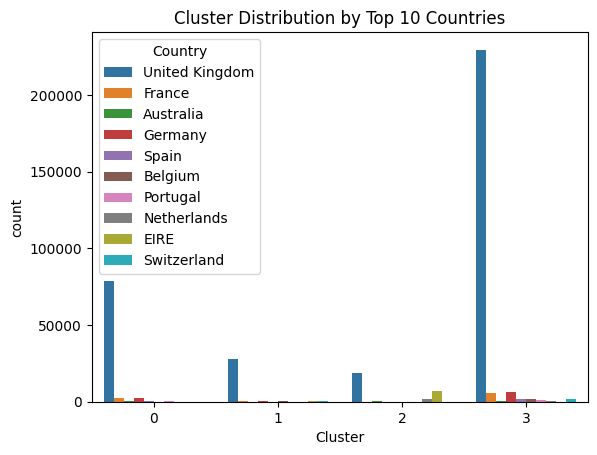

Ethical note: Watch for biases—e.g., UK may dominate due to dataset skew; adjust features if needed for fairness.


In [ ]:
def perform_bias_check(rfm, cleaned_file='data/cleaned_online_retail.csv'):
    """Merge clusters with cleaned data and check geographic bias."""
    df_clean = pd.read_csv(cleaned_file)
    df_clean_with_clusters = df_clean.merge(rfm[['CustomerID', 'Cluster']], on='CustomerID', how='left')

    # Visualize cluster distribution by top countries
    top_countries = df_clean_with_clusters['Country'].value_counts().head(10).index
    sns.countplot(x='Cluster', hue='Country', data=df_clean_with_clusters[df_clean_with_clusters['Country'].isin(top_countries)])
    plt.title('Cluster Distribution by Top 10 Countries')
    plt.show()

    # Note
    print("Ethical note: Watch for biases—e.g., UK may dominate due to dataset skew; adjust features if needed for fairness.")

perform_bias_check(rfm)

## 9. Pricing Bias Check and Other Potential Biases
Check for pricing bias by examining how clusters relate to average UnitPrice per customer. Also check product type skew and time-based bias.

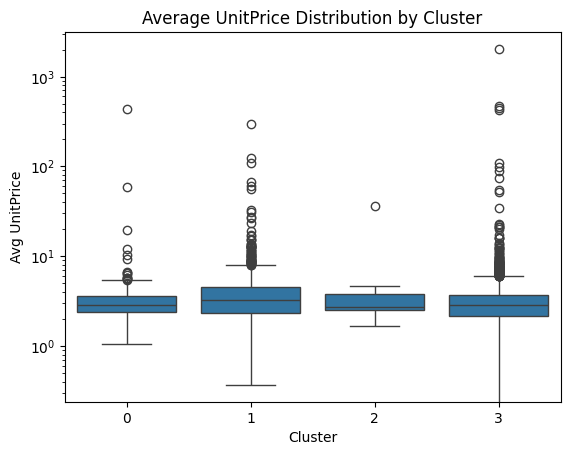

Mean Average UnitPrice per Cluster:
Cluster
0    5.523865
1    4.462899
2    5.553183
3    4.388282
Name: AvgUnitPrice, dtype: float64

Top 5 Products (%) per Cluster (check for skew):
Cluster  Description                       
0        JUMBO BAG RED RETROSPOT               0.571746
         WHITE HANGING HEART T-LIGHT HOLDER    0.523313
         REGENCY CAKESTAND 3 TIER              0.511500
         LUNCH BAG RED RETROSPOT               0.437078
         PARTY BUNTING                         0.429991
1        WHITE HANGING HEART T-LIGHT HOLDER    0.707470
         REGENCY CAKESTAND 3 TIER              0.664692
         PARTY BUNTING                         0.480421
         ASSORTED COLOUR BIRD ORNAMENT         0.454097
         REX CASH+CARRY JUMBO SHOPPER          0.401448
2        JUMBO BAG RED RETROSPOT               0.431746
         REGENCY CAKESTAND 3 TIER              0.372073
         CARRIAGE                              0.340482
         WHITE HANGING HEART T-LIGHT HOLDER

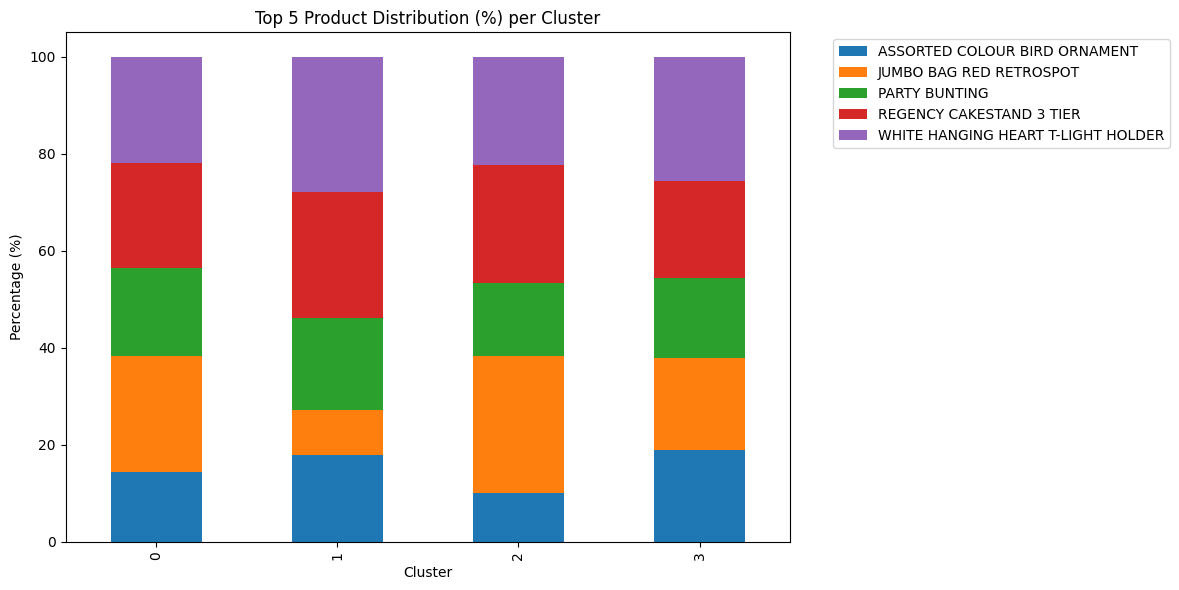

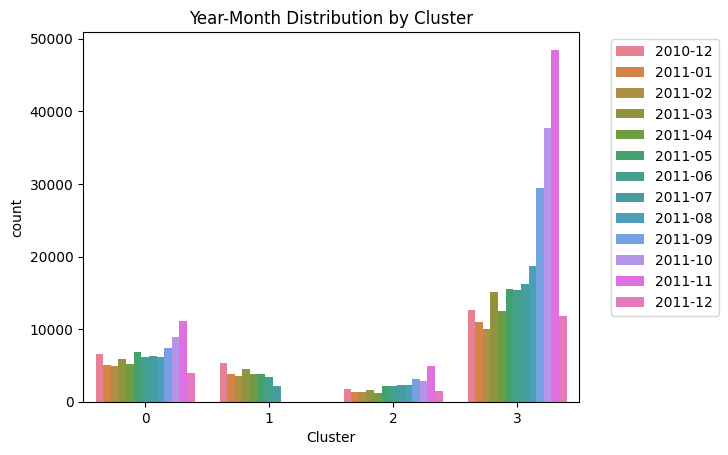


ARI between Cluster and YearMonth: 0.0206 (High = potential time/seasonal bias)
Bias checks complete; review results for any concerns.


In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import adjusted_rand_score

def load_and_merge_data(cleaned_file='data/cleaned_online_retail.csv', rfm_file='data/rfm_with_clusters.csv'):
    """Load cleaned data and RFM with clusters, merge, and add YearMonth if missing."""
    df_clean = pd.read_csv(cleaned_file)
    rfm = pd.read_csv(rfm_file)
    df_clean_with_clusters = df_clean.merge(rfm[['CustomerID', 'Cluster']], on='CustomerID', how='left')

    if 'YearMonth' not in df_clean_with_clusters.columns:
        df_clean_with_clusters['InvoiceDate'] = pd.to_datetime(df_clean_with_clusters['InvoiceDate'])
        df_clean_with_clusters['YearMonth'] = df_clean_with_clusters['InvoiceDate'].dt.to_period('M')

    return df_clean_with_clusters, rfm

df_clean_with_clusters, rfm = load_and_merge_data()

def check_pricing_bias(df_clean_with_clusters, rfm):
    """Check for pricing bias with visualization and means."""
    customer_avg_price = df_clean_with_clusters.groupby('CustomerID')['UnitPrice'].mean().reset_index(name='AvgUnitPrice')
    rfm_with_price = rfm.merge(customer_avg_price, on='CustomerID')

    sns.boxplot(x='Cluster', y='AvgUnitPrice', data=rfm_with_price)
    plt.title('Average UnitPrice Distribution by Cluster')
    plt.ylabel('Avg UnitPrice')
    plt.yscale('log')  # Log scale for skew
    plt.show()

    means = rfm_with_price.groupby('Cluster')['AvgUnitPrice'].mean()
    print("Mean Average UnitPrice per Cluster:")
    print(means)

    return means

pricing_means = check_pricing_bias(df_clean_with_clusters, rfm)

def check_product_bias(df_clean_with_clusters):
    """Check for product type skew with top products and stacked bar plot."""
    top_products_per_cluster = df_clean_with_clusters.groupby('Cluster')['Description'].value_counts(normalize=True).groupby(level=0).head(5) * 100
    print("\nTop 5 Products (%) per Cluster (check for skew):")
    print(top_products_per_cluster)

    top_products = df_clean_with_clusters['Description'].value_counts().head(5).index
    product_counts = df_clean_with_clusters[df_clean_with_clusters['Description'].isin(top_products)].groupby(['Cluster', 'Description']).size().unstack(fill_value=0)
    product_counts = product_counts.div(product_counts.sum(axis=1), axis=0) * 100  # To percentages
    product_counts.plot(kind='bar', stacked=True, figsize=(12, 6))
    plt.title('Top 5 Product Distribution (%) per Cluster')
    plt.ylabel('Percentage (%)')
    plt.xlabel('Cluster')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

check_product_bias(df_clean_with_clusters)

def check_time_bias(df_clean_with_clusters):
    """Check for time-based bias with countplot and ARI."""
    sns.countplot(x='Cluster', hue='YearMonth', data=df_clean_with_clusters)
    plt.title('Year-Month Distribution by Cluster')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

    month_encoder = LabelEncoder()
    df_clean_with_clusters['YearMonth_Label'] = month_encoder.fit_transform(df_clean_with_clusters['YearMonth'])
    ari_time = adjusted_rand_score(df_clean_with_clusters['YearMonth_Label'], df_clean_with_clusters['Cluster'])
    print(f"\nARI between Cluster and YearMonth: {ari_time:.4f} (High = potential time/seasonal bias)")

    return ari_time

ari_time = check_time_bias(df_clean_with_clusters)

# Notes: If ARI >0.2 or products/prices heavily skewed, consider adding time-normalized features or stratified clustering in future days.
print("Bias checks complete; review results for any concerns.")

## 10. Unit Tests with pytest
Add simple unit tests to verify functions (e.g., scaling mean=0, clusters unique). Save as 'tests/test_clustering.py' and run pytest tests/ in terminal.

In [ ]:
# Example tests in notebook; save as tests/test_clustering.py for pytest
def test_scale_rfm(rfm):
    rfm_scaled = scale_rfm(rfm)
    assert rfm_scaled.shape[1] == 3, "Scaled RFM has 3 features"
    assert np.allclose(rfm_scaled.mean(axis=0), 0, atol=1e-6), "Scaled mean ~0"

def test_compute_elbow(rfm_scaled):
    inertia, k_range = compute_elbow(rfm_scaled)
    assert len(inertia) == len(k_range), "Inertia matches k_range"

def test_fit_and_assign_clusters(rfm, rfm_scaled):
    rfm, kmeans = fit_and_assign_clusters(rfm, rfm_scaled)
    assert 'Cluster' in rfm.columns, "Cluster column added"
    assert len(rfm['Cluster'].unique()) == 4, "4 unique clusters"

# Run manually (demo; use pytest in terminal)
test_scale_rfm(rfm)
test_compute_elbow(rfm_scaled)
test_fit_and_assign_clusters(rfm.copy(), rfm_scaled)  # Copy to avoid modifying
print("Manual tests passed; run pytest for full verification.")